In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore, f_oneway
import warnings
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
df = pd.read_csv('../trabajo_final/data/income_data.csv')

DUPLICADOS

In [3]:
print("Duplicados antes:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicados después:", df.duplicated().sum())

Duplicados antes: 52
Duplicados después: 0


VALORES NULOS

In [4]:
cols_with_missing = ['workclass', 'occupation', 'native-country']

for col in cols_with_missing:
    df[col] = df[col].replace('?', 'Unknown')

In [5]:
for col in cols_with_missing:
    print(f"{col}: {(df[col] == '?').sum()} valores '?' restantes")

workclass: 0 valores '?' restantes
occupation: 0 valores '?' restantes
native-country: 0 valores '?' restantes


AGRUPAMOS PAÍSES

In [6]:
top_countries = [
    'United-States',
    'Mexico',
    "Unknown",
]

df['native-country'] = df['native-country'].apply(
    lambda x: x if x in top_countries else 'Other'
)

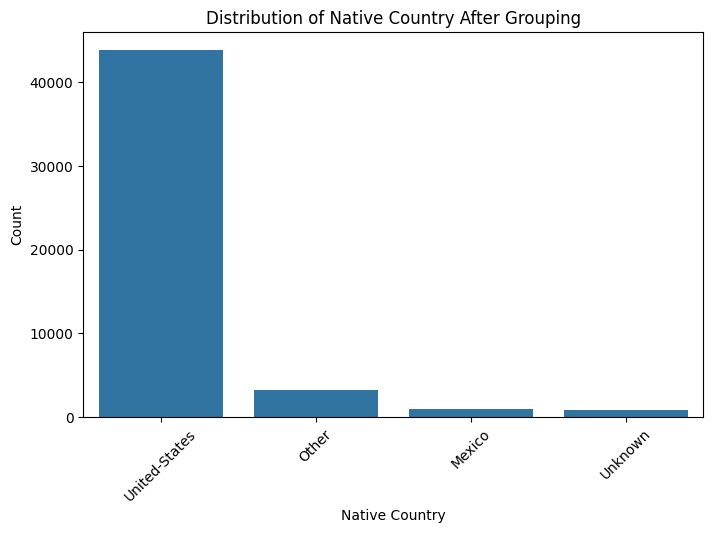

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='native-country',
    order=df['native-country'].value_counts().index
)

plt.title('Distribution of Native Country After Grouping')
plt.xlabel('Native Country')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

AGRUPAMOS RAZAS

In [8]:
# Race
df['race'] = df['race'].replace({
    'Amer-Indian-Eskimo': 'Other',
    'Asian-Pac-Islander': 'Other',
    'Other': 'Other'
})

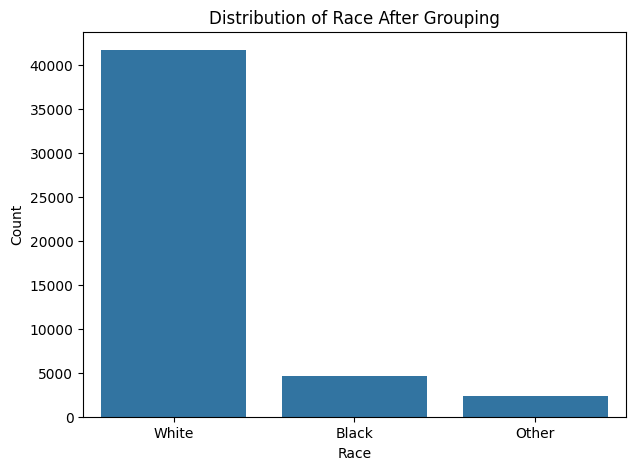

In [9]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='race',
    order=df['race'].value_counts().index
)

plt.title('Distribution of Race After Grouping')
plt.xlabel('Race')
plt.ylabel('Count')

plt.show()

VARIABLE ELIMINAR

In [10]:
df = df.drop(columns=[
    'fnlwgt',
    'education'
], errors='ignore')

In [11]:
df.head()

,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,Unknown,10,Never-married,Unknown,Own-child,White,Female,0,0,30,United-States,<=50K


In [12]:
X = df.drop('income', axis=1)
y = df['income']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(39032, 12)
(9758, 12)


In [14]:
df.to_csv('../trabajo_final/data/clean/df_clean.csv', index=False)

print("CSV limpio guardado correctamente")
print("Shape final:", df.shape)
print(df.head())

CSV limpio guardado correctamente
Shape final: (48790, 13)
   age  workclass  educational-num      marital-status         occupation  \
0   25    Private                7       Never-married  Machine-op-inspct   
1   38    Private                9  Married-civ-spouse    Farming-fishing   
2   28  Local-gov               12  Married-civ-spouse    Protective-serv   
3   44    Private               10  Married-civ-spouse  Machine-op-inspct   
4   18    Unknown               10       Never-married            Unknown   

  relationship   race  gender  capital-gain  capital-loss  hours-per-week  \
0    Own-child  Black    Male             0             0              40   
1      Husband  White    Male             0             0              50   
2      Husband  White    Male             0             0              40   
3      Husband  Black    Male          7688             0              40   
4    Own-child  White  Female             0             0              30   

  native-countr